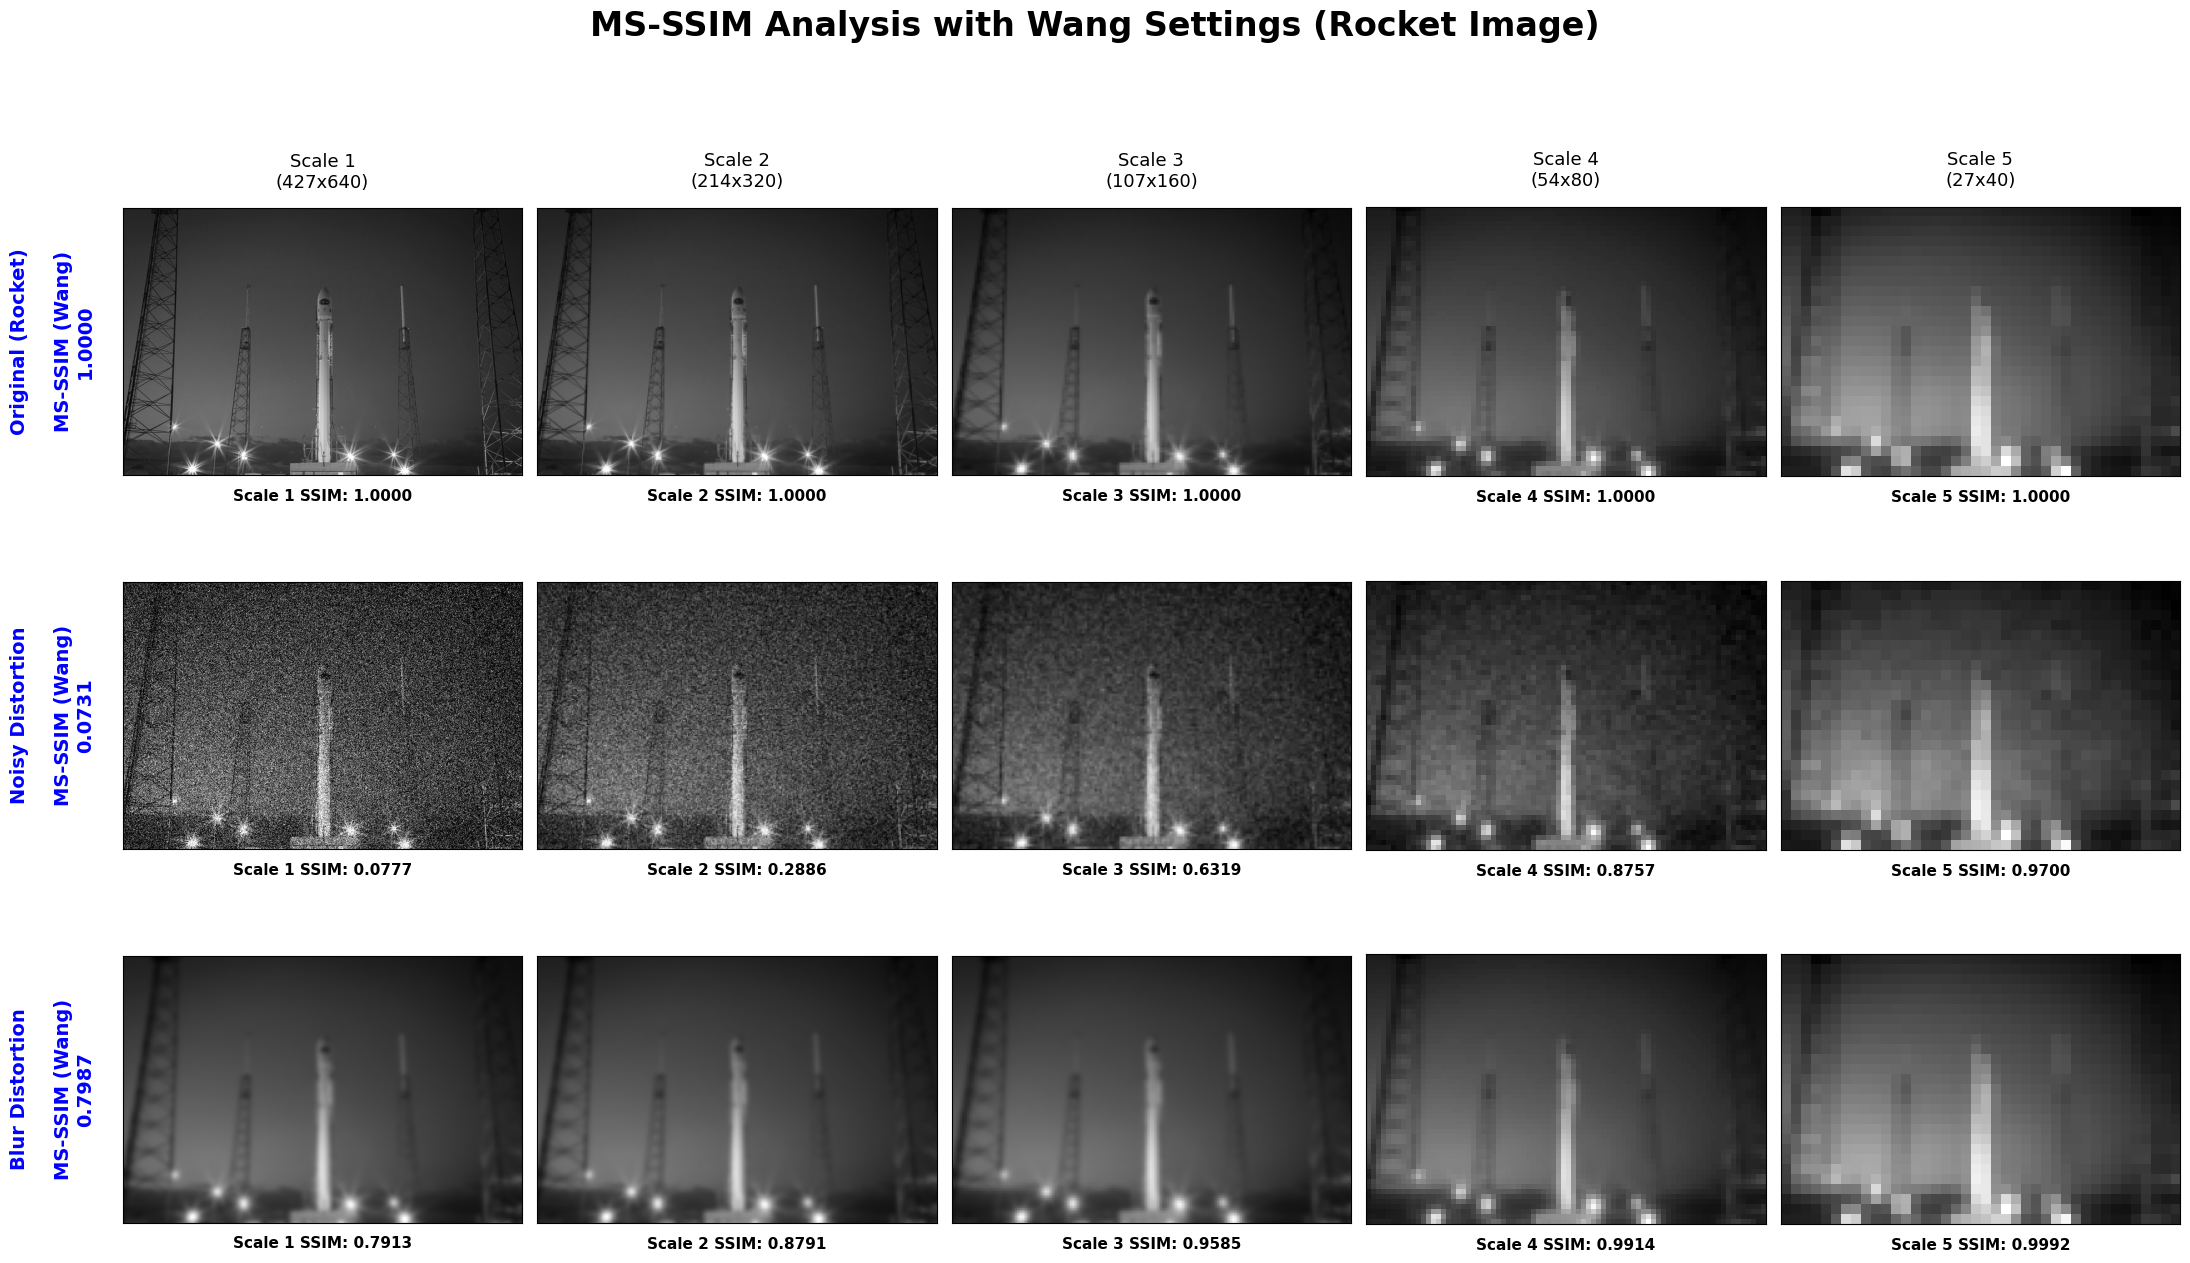

=== MS-SSIM 결과 (Wang 설정) ===
Noisy: 0.0731
Blurred: 0.7987


In [45]:
# 전체 코드: Wang 설정으로 MS-SSIM 계산 및 시각화 (로켓 이미지)
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.transform import pyramid_gaussian
from skimage.util import random_noise
from skimage.filters import gaussian
from skimage.metrics import structural_similarity

# 1. 이미지 준비
original_color = img_as_float(data.rocket())
original = np.mean(original_color, axis=2)
noisy = random_noise(original, mode='gaussian', var=0.05, clip=True)
blurred = gaussian(original, sigma=4)

# 2. 피라미드 생성
original_pyramid = list(pyramid_gaussian(original, max_layer=4, channel_axis=None))
noisy_pyramid = list(pyramid_gaussian(noisy, max_layer=4, channel_axis=None))
blurred_pyramid = list(pyramid_gaussian(blurred, max_layer=4, channel_axis=None))

# 3. 각 스케일 SSIM 계산 (시각화용)
noisy_scales = [structural_similarity(o, d, data_range=1.0) for o, d in zip(original_pyramid, noisy_pyramid)]
blurred_scales = [structural_similarity(o, d, data_range=1.0) for o, d in zip(original_pyramid, blurred_pyramid)]

# 4. MS-SSIM 계산 (Wang 설정)
ms_ssim_noisy = structural_similarity(original, noisy, multiscale=True, gaussian_weights=True, sigma=1.5, use_sample_covariance=False, data_range=1.0)
ms_ssim_blurred = structural_similarity(original, blurred, multiscale=True, gaussian_weights=True, sigma=1.5, use_sample_covariance=False, data_range=1.0)

# 5. 시각화
fig, axes = plt.subplots(3, 5, figsize=(22, 12))
titles = ["Original (Rocket)", "Noisy Distortion", "Blur Distortion"]
pyramids = [original_pyramid, noisy_pyramid, blurred_pyramid]
scale_scores_list = [[1.0]*5, noisy_scales, blurred_scales]
final_ms_scores = [1.0, ms_ssim_noisy, ms_ssim_blurred]

for row in range(3):
    for col in range(5):
        ax = axes[row, col]
        ax.imshow(pyramids[row][col], cmap='gray')
        
        score_text = f"Scale {col+1} SSIM: {scale_scores_list[row][col]:.4f}"
        ax.set_xlabel(score_text, fontsize=11, fontweight='bold', labelpad=10)
        
        if col == 0:
            row_label = f"{titles[row]}\n\nMS-SSIM (Wang)\n{final_ms_scores[row]:.4f}"
            ax.set_ylabel(row_label, fontsize=14, fontweight='extra bold', color='blue', labelpad=20)
        
        if row == 0:
            ax.set_title(f'Scale {col+1}\n({pyramids[row][col].shape[0]}x{pyramids[row][col].shape[1]})', fontsize=13, pad=15)
            
        ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.suptitle('MS-SSIM Analysis with Wang Settings (Rocket Image)', fontsize=24, y=1.08, fontweight='bold')
plt.show()

# 출력
print("=== MS-SSIM 결과 (Wang 설정) ===")
print(f"Noisy: {ms_ssim_noisy:.4f}")
print(f"Blurred: {ms_ssim_blurred:.4f}")

## 💡 Conclusion & Key Findings

### 1. Final MS-SSIM Scores
* **Noisy Distortion (0.0731):** The score is severely low. High-frequency random noise fundamentally destroys the structural similarity of the image at the pixel level. To the human eye, the original structure is nearly unrecognizable.
* **Blur Distortion (0.7987):** The score is relatively high. While a Gaussian blur smudges fine details, it preserves the global structure, contours, and large patterns. The image remains visually recognizable.

### 2. Scale-wise SSIM Behavior (Scale 1 to 5)
* **Scale 1 (Original Resolution):** The Noisy image scores poorly (0.0779) because the noise is distinctly visible at full resolution.
* **Scale 2 to 5 (Downsampled):** As the image is progressively downsampled, the SSIM scores for both distortions increase. The low-pass filtering effect smooths out the noise and blur, making the structural differences less pronounced. This perfectly validates the MS-SSIM design intention: **distortions become less perceptible at lower resolutions, simulating the effect of viewing an image from a distance.**

### 3. The MS-SSIM Advantage
* **Human Visual System (HVS) Alignment:** MS-SSIM proves to be far more realistic than single-scale SSIM. By combining multiple viewing scales, it mimics how humans actually perceive quality. 
* **Distortion Sensitivity:** The algorithm correctly identifies that random noise (which shatters structure) is a more severe degradation than blurring (which softens but retains structure).
* **Practical Application:** In practical Image Quality Assessment (IQA), MS-SSIM provides a highly reliable metric for evaluating compression algorithms (like JPEG/JPEG2000) or denoising models, as it closely aligns with subjective human evaluation (MOS).